<a href="https://colab.research.google.com/github/pedroyoshikadogarcia/Checkpoint-2-SERS-02.2026/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


Execute a célula abaixo. Caso a conexão com a API falhe, pule para a etapa dos imports

In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


##Imports necessários para as tarefas:

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [ ]:
df = pd.read_csv('/content/aneel_classificacao_orange.csv')
df.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [72]:
df.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000


In [73]:
df.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [74]:
df['fonte'].value_counts()

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


In [ ]:
df.columns

Index(['potencia_kw', 'latitude', 'longitude', 'fonte'], dtype='object')

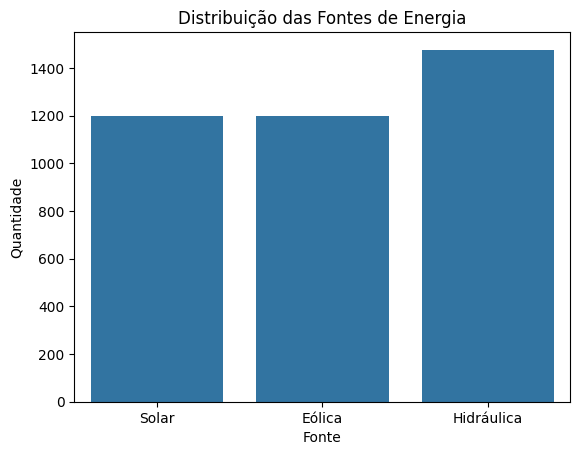

In [75]:
sns.countplot(data=df, x='fonte')

plt.title('Distribuição das Fontes de Energia')
plt.xlabel('Fonte')
plt.ylabel('Quantidade')

plt.show()

In [76]:
X = df.drop('fonte', axis=1)
Y = df['fonte']


In [ ]:
X

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000
...,...,...,...
3871,2000.00,0.000000,0.000000
3872,1500.00,0.000000,0.000000
3873,710.00,0.000000,0.000000
3874,297.50,0.000000,0.000000


In [ ]:
Y

,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar
...,...
3871,Hidráulica
3872,Hidráulica
3873,Hidráulica
3874,Hidráulica


In [77]:
# Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [78]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [79]:
# Métricas
accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average='macro'
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average='macro'
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average='macro'
)

In [80]:
# Visualizando as métricas
print("Métricas KNN:")
print(f"Accuracy: {accuracy_knn}")
print(f"Precision: {precision_knn}")
print(f"Recall: {recall_knn}")
print(f"F1: {f1_knn}")

Métricas KNN:
Accuracy: 0.8685567010309279
Precision: 0.8694143981093042
Recall: 0.8672672672672673
F1: 0.8679681345060017


In [81]:
# Regressão Logística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(
    X_train,
    y_train
)
y_pred_log = log_reg.predict(
    X_test
)

In [82]:
accuracy_log = accuracy_score(
    y_test,
    y_pred_log
)
precision_log = precision_score(
    y_test,
    y_pred_log,
    average='macro'
)
recall_log = recall_score(
    y_test,
    y_pred_log,
    average='macro'
)
f1_log = f1_score(
    y_test,
    y_pred_log,
    average='macro'
)

In [83]:
print("Métricas Regressão Logística:")
print(f"Accuracy: {accuracy_log}")
print(f"Precision: {precision_log}")
print(f"Recall: {recall_log}")
print(f"F1: {f1_log}")

Métricas Regressão Logística:
Accuracy: 0.8182989690721649
Precision: 0.8209991698316683
Recall: 0.8152027027027028
F1: 0.812938708118307


In [84]:
# Random Forest Classifier
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(
    X_train,
    y_train
)
y_pred_rf = rf.predict(
    X_test
)

In [85]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)
precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='macro'
)
recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='macro'
)
f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='macro'
)

In [86]:
print("Métricas Random Forest:")
print(f"Accuracy: {accuracy_rf}")
print(f"Precision: {precision_rf}")
print(f"Recall: {recall_rf}")
print(f"F1: {f1_rf}")

Métricas Random Forest:
Accuracy: 0.9755154639175257
Precision: 0.9768806647225744
Recall: 0.9741366366366367
F1: 0.9752515228975418


In [87]:
df_classificacao = pd.DataFrame({
    'Algoritmo': [
        'KNN',
        'Regressão Logística',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_knn,
        accuracy_log,
        accuracy_rf
    ],
    'Precision (macro)': [
        precision_knn,
        precision_log,
        precision_rf
    ],
    'Recall (macro)': [
        recall_knn,
        recall_log,
        recall_rf
    ],
    'F1-Score (macro)': [
        f1_knn,
        f1_log,
        f1_rf
    ]
})

df_classificacao

,Algoritmo,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,KNN,0.868557,0.869414,0.867267,0.867968
1,Regressão Logística,0.818299,0.820999,0.815203,0.812939
2,Random Forest,0.975515,0.976881,0.974137,0.975252


In [88]:
tabela_classificacao_estilizada = df_classificacao.style.format({
    'Accuracy': '{:.4f}',
    'Precision (macro)': '{:.4f}',
    'Recall (macro)': '{:.4f}',
    'F1-Score (macro)': '{:.4f}'
})

display(tabela_classificacao_estilizada)

,Algoritmo,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,KNN,0.8686,0.8694,0.8673,0.8680
1,Regressão Logística,0.8183,0.8210,0.8152,0.8129
2,Random Forest,0.9755,0.9769,0.9741,0.9753


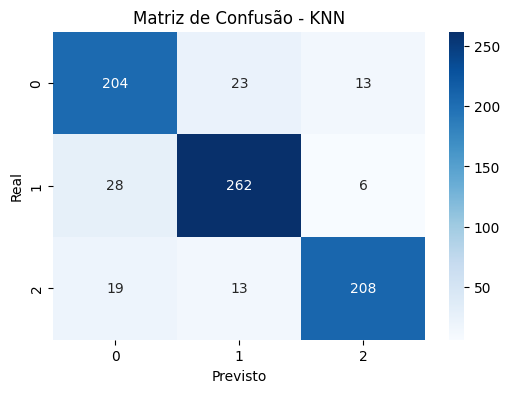

In [89]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão - KNN')

plt.xlabel('Previsto')

plt.ylabel('Real')

plt.show()

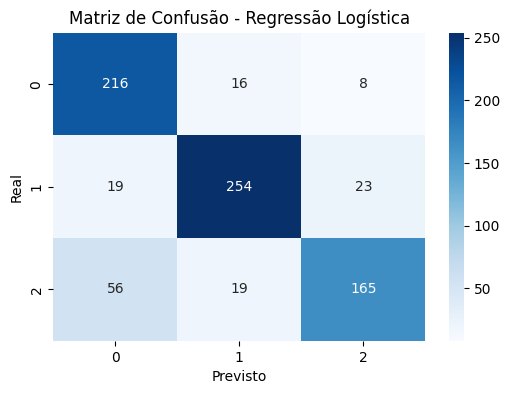

In [90]:
cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão - Regressão Logística')

plt.xlabel('Previsto')

plt.ylabel('Real')

plt.show()

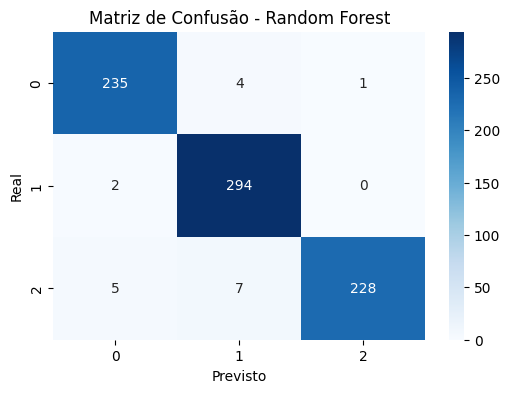

In [91]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão - Random Forest')

plt.xlabel('Previsto')

plt.ylabel('Real')

plt.show()

O Random Forest apresentou o melhor desempenho entre os três modelos avaliados, com aproximadamente 97,5% de Accuracy e resultados equilibrados de Precision, Recall e F1-Score.

O KNN apresentou desempenho intermediário, enquanto a Regressão Logística apresentou o menor desempenho entre os três modelos.

A matriz de confusão permite observar quais classes foram mais confundidas pelo modelo. A confusão pode ocorrer principalmente entre fontes Solar e Eólica, pois potência e localização podem apresentar valores semelhantes entre diferentes tipos de empreendimentos.

Na prática, potência e localização não são suficientes para classificar uma fonte com total precisão. Outras características do empreendimento poderiam melhorar a classificação, como informações sobre equipamentos, características físicas, comportamento da geração e dados regulatórios.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [ ]:
df_reg = pd.read_csv('/content/meteo_regressao_orange.csv')
df_reg.head(20)

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0
5,2025-04-01T12:00,34.2,31,36,19.2,12,905.0
6,2025-04-01T13:00,35.0,30,50,19.5,13,910.0
7,2025-04-01T14:00,35.0,30,19,17.1,14,733.0
8,2025-04-01T15:00,35.3,30,30,17.3,15,699.0
9,2025-04-01T16:00,35.0,30,18,17.6,16,443.0


In [92]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


In [93]:
df_reg.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


In [94]:
df_reg.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


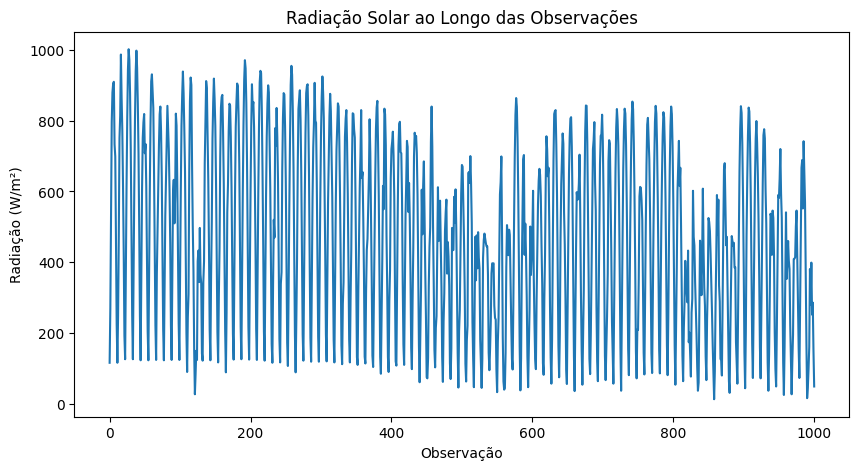

In [96]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_reg['radiacao_w_m2']
)

plt.title(
    'Radiação Solar ao Longo das Observações'
)

plt.xlabel('Observação')

plt.ylabel('Radiação (W/m²)')

plt.show()

In [97]:
media_hora = df_reg.groupby(
    'hora'
)['radiacao_w_m2'].mean()

media_hora

,radiacao_w_m2
hora,
7,83.395604
8,260.494505
9,434.824176
10,605.340659
11,693.428571
12,727.912088
13,721.890110
14,654.879121
15,523.318681


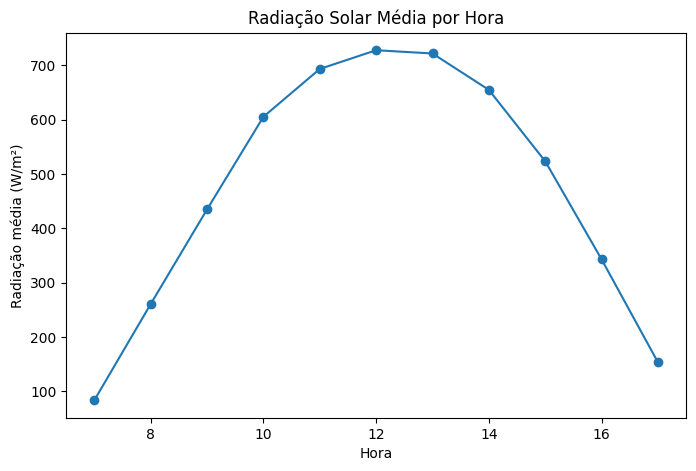

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(
    media_hora.index,
    media_hora.values,
    marker='o'
)

plt.title(
    'Radiação Solar Média por Hora'
)

plt.xlabel('Hora')

plt.ylabel('Radiação média (W/m²)')

plt.show()

In [99]:
X_reg = df_reg[
    [
        'temperatura_c',
        'umidade_pct',
        'nuvens_pct',
        'vento_kmh',
        'hora'
    ]
]

Y_reg = df_reg[
    'radiacao_w_m2'
]

In [100]:
X_reg

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11
...,...,...,...,...,...
996,26.9,56,100,18.5,13
997,26.8,56,81,16.8,14
998,27.3,55,82,15.9,15
999,27.2,54,100,15.8,16


In [101]:
Y_reg

,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0
...,...
996,399.0
997,252.0
998,286.0
999,151.0


In [103]:
ponto_corte = int(
    len(df_reg) * 0.8
)
X_train_reg = X_reg.iloc[
    :ponto_corte
]
X_test_reg = X_reg.iloc[
    ponto_corte:
]
y_train_reg = Y_reg.iloc[
    :ponto_corte
]
y_test_reg = Y_reg.iloc[
    ponto_corte:
]

In [104]:
print("Dados de treino:", X_train_reg.shape)
print("Dados de teste:", X_test_reg.shape)

Dados de treino: (800, 5)
Dados de teste: (201, 5)


In [105]:
# Regressão Linear
modelo_linear = LinearRegression()

modelo_linear.fit(
    X_train_reg,
    y_train_reg
)

y_pred_linear = modelo_linear.predict(
    X_test_reg
)

In [106]:
mae_linear = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)
mse_linear = mean_squared_error(
    y_test_reg,
    y_pred_linear
)
r2_linear = r2_score(
    y_test_reg,
    y_pred_linear
)

In [107]:
print("Regressão Linear:")
print(f"MAE: {mae_linear}")
print(f"MSE: {mse_linear}")
print(f"R²: {r2_linear}")

Regressão Linear:
MAE: 145.2048850741199
MSE: 30034.201092064613
R²: 0.35984495652041326


In [108]:
# Decision Tree

modelo_arvore = DecisionTreeRegressor(
    random_state=42
)
modelo_arvore.fit(
    X_train_reg,
    y_train_reg
)
y_pred_arvore = modelo_arvore.predict(
    X_test_reg
)

In [109]:
mae_arvore = mean_absolute_error(
    y_test_reg,
    y_pred_arvore
)
mse_arvore = mean_squared_error(
    y_test_reg,
    y_pred_arvore
)
r2_arvore = r2_score(
    y_test_reg,
    y_pred_arvore
)

In [110]:
print("Decision Tree:")
print(f"MAE: {mae_arvore}")
print(f"MSE: {mse_arvore}")
print(f"R²: {r2_arvore}")

Decision Tree:
MAE: 88.7910447761194
MSE: 15291.1592039801
R²: 0.6740811365325959


In [111]:
# Random Forest
modelo_rf = RandomForestRegressor(
    random_state=42
)
modelo_rf.fit(
    X_train_reg,
    y_train_reg
)
y_pred_rf_reg = modelo_rf.predict(
    X_test_reg
)

In [112]:
mae_rf_reg = mean_absolute_error(
    y_test_reg,
    y_pred_rf_reg
)
mse_rf_reg = mean_squared_error(
    y_test_reg,
    y_pred_rf_reg
)
r2_rf_reg = r2_score(
    y_test_reg,
    y_pred_rf_reg
)

In [113]:
print("Random Forest:")
print(f"MAE: {mae_rf_reg}")
print(f"MSE: {mse_rf_reg}")
print(f"R²: {r2_rf_reg}")

Random Forest:
MAE: 66.80417910447761
MSE: 7307.417901492537
R²: 0.8442482152225645


In [114]:
df_regressao = pd.DataFrame({
    'Algoritmo': [
        'Regressão Linear',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mae_linear,
        mae_arvore,
        mae_rf_reg
    ],
    'MSE': [
        mse_linear,
        mse_arvore,
        mse_rf_reg
    ],
    'R²': [
        r2_linear,
        r2_arvore,
        r2_rf_reg
    ]
})
df_regressao

,Algoritmo,MAE,MSE,R²
0,Regressão Linear,145.204885,30034.201092,0.359845
1,Decision Tree,88.791045,15291.159204,0.674081
2,Random Forest,66.804179,7307.417901,0.844248


In [115]:
tabela_regressao_estilizada = df_regressao.style.format({
    'MAE': '{:.2f}',
    'MSE': '{:.2f}',
    'R²': '{:.4f}'
})

display(
    tabela_regressao_estilizada
)

,Algoritmo,MAE,MSE,R²
0,Regressão Linear,145.20,30034.20,0.3598
1,Decision Tree,88.79,15291.16,0.6741
2,Random Forest,66.80,7307.42,0.8442


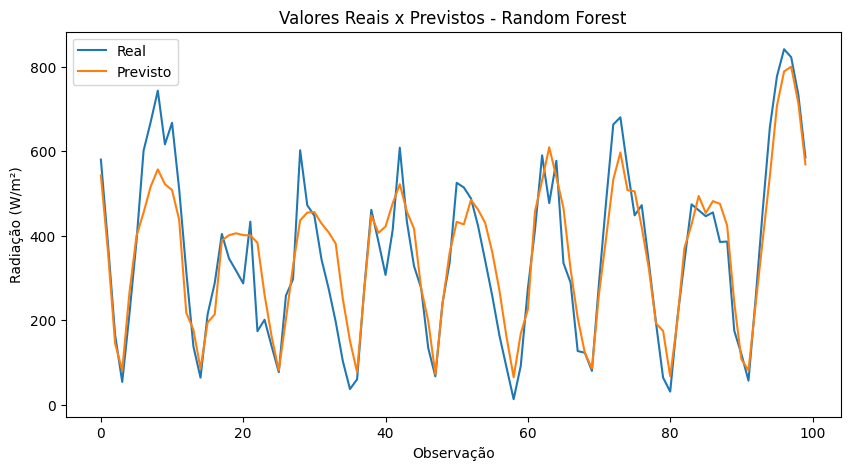

In [116]:
# Real x Previsto
plt.figure(figsize=(10, 5))
plt.plot(
    y_test_reg.values[:100],
    label='Real'
)
plt.plot(
    y_pred_rf_reg[:100],
    label='Previsto'
)
plt.title(
    'Valores Reais x Previstos - Random Forest'
)
plt.xlabel('Observação')
plt.ylabel('Radiação (W/m²)')
plt.legend()
plt.show()

In [117]:
importancias = pd.DataFrame({
    'Variável': X_reg.columns,
    'Importância': modelo_rf.feature_importances_
})
importancias = importancias.sort_values(
    'Importância',
    ascending=False
)
importancias

,Variável,Importância
4,hora,0.488455
0,temperatura_c,0.301028
1,umidade_pct,0.173311
2,nuvens_pct,0.021748
3,vento_kmh,0.015458


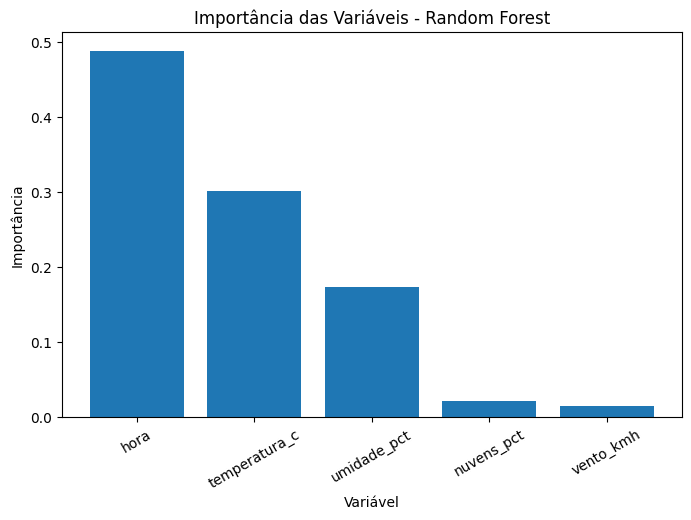

In [118]:
plt.figure(figsize=(8, 5))
plt.bar(
    importancias['Variável'],
    importancias['Importância']
)
plt.title(
    'Importância das Variáveis - Random Forest'
)
plt.xlabel('Variável')
plt.ylabel('Importância')
plt.xticks(rotation=30)
plt.show()

Conclusão

Foram utilizados três algoritmos de regressão: Regressão Linear, Decision Tree e Random Forest. Os três modelos utilizaram a mesma divisão temporal dos dados, mantendo aproximadamente 80% das primeiras observações para treinamento e os 20% finais para teste.

A comparação foi realizada utilizando MAE, MSE e R². O Random Forest apresentou o melhor desempenho entre os modelos avaliados, apresentando o menor erro e o maior valor de R².

A variável hora possui importância para a previsão porque a radiação solar varia naturalmente durante o dia. Os valores são menores no início e no final do período de geração solar e tendem a ser maiores durante as horas de maior incidência solar.

A radiação solar medida em W/m² não representa diretamente a energia elétrica produzida por um sistema fotovoltaico. A quantidade de energia produzida também depende de fatores como potência instalada, eficiência dos painéis, área disponível, orientação, inclinação e perdas do sistema.

Portanto, o modelo realiza uma estimativa da radiação solar com base nas condições meteorológicas e na hora local. Essa estimativa não deve ser interpretada como uma previsão direta da quantidade de energia elétrica produzida por um painel fotovoltaico.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)